In [169]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# <span style="color:#2a9d8fff"> **Part A**: Data Understanding & Cleaning</span> #

**Step 1**: Load the dataset into the `data` DataFrame and see the detailed data.

In [170]:
data = pd.read_excel('Project Data.xlsx', index_col=0)

In [171]:
print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns.")
data.head()

The dataset has 10008 rows and 15 columns.


,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
Patient ID,,,,,,,,,,,,,,,
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-02-22,Endocrinology,110,2,38839.0,293.014042,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-01-21,Emergency,76,4,52219.0,287.208982,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-06-13,Neurology,17,5,41491.0,241.254507,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-03-24,Emergency,15,3,34944.0,221.177483,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-03-19,Neurology,99,1,39248.0,219.743794,0.0


In [172]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        9952 non-null   float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         8098 non-null   object        
 5   Family History             8015 non-null   object        
 6   Education Level            9979 non-null   object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

In [173]:
data.describe(include='all')

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
count,9952.000000,10008,10008,10008,8098,8015,9979,10008,10008,10008,10008.000000,10008.000000,9.854000e+03,10008.000000,9958.000000
unique,NaN,3,8,10,4,4,8,4,NaN,13,NaN,NaN,NaN,NaN,NaN
top,NaN,Other,Birmingham,Retired,Provider D,Heart Disease,Undergraduate,Divorced,NaN,Psychiatry,NaN,NaN,NaN,NaN,NaN
freq,NaN,3417,1473,3601,2165,2235,4160,2893,NaN,1361,NaN,NaN,NaN,NaN,NaN
mean,50.635651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-31 14:53:14.244604160,NaN,67.807654,3.202338,4.340276e+04,187.263022,115.429366
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:00:00,NaN,15.000000,1.000000,0.000000e+00,50.036762,0.000000
25%,23.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-15 00:00:00,NaN,41.000000,2.000000,3.115775e+04,111.316562,59.692518
50%,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-31 00:00:00,NaN,68.000000,3.000000,4.087650e+04,159.531115,115.938998
75%,75.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-05-16 00:00:00,NaN,94.000000,5.000000,5.072175e+04,199.820999,165.437958
max,195.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-30 00:00:00,NaN,600.000000,6.000000,1.197090e+07,39999.222018,421.887836


**Step 2**: Check the quality of the data.

In [174]:
missing_count = data.isna().sum()
missing_percentage = (data.isna().mean()*100).round(2)
missing_summary = pd.DataFrame({'Count of Missing Values': missing_count, '% of Missing Values': missing_percentage}).sort_values(by = '% of Missing Values', ascending = False)
missing_summary

,Count of Missing Values,% of Missing Values
Family History,1993,19.91
Insurance Provider,1910,19.08
Approximate Annual Income,154,1.54
Age,56,0.56
Insurance Coverage,50,0.50
Education Level,29,0.29
Gender,0,0.00
Profession,0,0.00
City of Residence,0,0.00
Marital Status,0,0.00


The most problematic variable is `Family History` with 19.91% of missing values.

**Step 3**: Exploring Missingness Type (MCAR, MAR, MNAR)

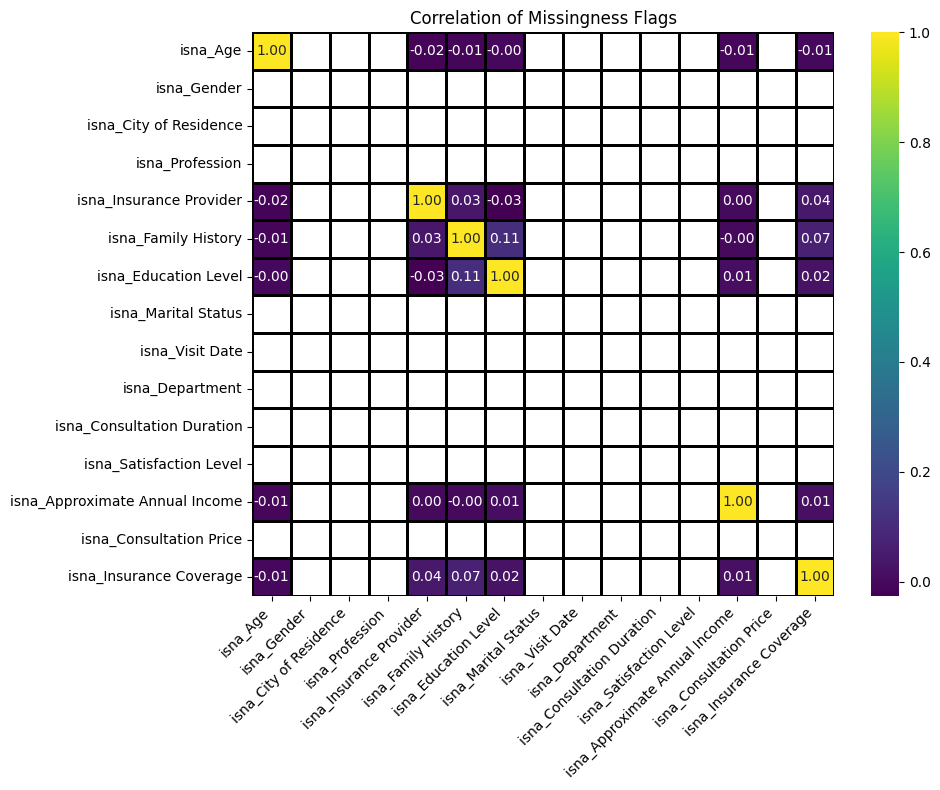

In [175]:
missing_flags = data.isna().astype(int).add_prefix("isna_")

# Compute "correlation of missingness flags" to see if missing patterns co-occur
corr_flags = missing_flags.corr(method='pearson')

# Visualize the correlation matrix of missingness flags
plt.figure(figsize=(10, 8))
sns.heatmap(corr_flags, annot=True, fmt=".2f", cmap="viridis", cbar=True, linewidths=1, linecolor='black')
plt.title("Correlation of Missingness Flags")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This shows that, for the majority of the variables, there is no correlation in their missingness, meaning the patter of missingness for those is unrelated to any variable. These missing values are **Missing Completely at Random (MCAR)**.

However, there are weak to moderate correlations between some variables:
- `isna_Family History` and `isna_Education Level` (corr = 0.11): this might indicate that if a patient's Family History is missing then there is a high probability the Education Level for that same patient will be missing too.
- `isna_Family History` and `isna_Insurance Coverage` (corr = 0.07): this might indicate that if a patient's Family History is missing then there is a high probability the Insurance Coverage for that same patient will be missing too.
- `isna_Insurance Provider` and `isna_Insurance Coverage` (corr = 0.04): this might indicate that if a patient's Insurance Provider is missing then there is a high probability the Insurance Coverage for that same patient will be missing too.

**Step 4**: Fill in the missing values for `Age`: inspect all cells of those patients and see if they have their age associated.

In [176]:
patients_with_nan_age = data.index[data['Age'].isna()].unique()

In [177]:
patients_rows = data.loc[data.index.isin(patients_with_nan_age)]
ages_of_patients = patients_rows.groupby(patients_rows.index)['Age'] \
                                      .apply(lambda x: x.dropna().iloc[0])
ages_of_patients

Patient ID
1009    20.0
1012     7.0
1023    82.0
1029    16.0
1031    71.0
1036    78.0
1048    98.0
1051    29.0
1057    42.0
1061    42.0
1065    55.0
1070    93.0
1084    98.0
1103    65.0
1108    57.0
1109     2.0
1112    94.0
1117    79.0
1118    52.0
1125    65.0
1128    91.0
1139    35.0
1144    89.0
1154    48.0
1175    82.0
1213    29.0
1232    18.0
1234    14.0
1251    93.0
1258    27.0
1260    52.0
1274    74.0
1276    98.0
1280    30.0
1286    59.0
1287    68.0
1294    89.0
1303    34.0
1304     0.0
1307    34.0
1325    10.0
1328    46.0
1333     0.0
1340    51.0
1356    51.0
1360     1.0
1365    99.0
1387    15.0
1390    12.0
1419    54.0
1426    60.0
1492    43.0
1495    23.0
Name: Age, dtype: float64

In [178]:
for patient in patients_with_nan_age:
   age_to_fill_in_with = ages_of_patients.get(patient)
   data.loc[patient, 'Age'] = data.loc[patient,'Age'].fillna(age_to_fill_in_with)

In [179]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         8098 non-null   object        
 5   Family History             8015 non-null   object        
 6   Education Level            9979 non-null   object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

**Step 4**: Fill in the missing values for `Insurance Provider` and `Insurance Coverage`: inspect all cells of those patients and see if they have their insurance provider associated.

The ones with Insurance Coverage = 0.0 are the ones with Insurance Provider = NaN.

Transform the NaN's in 0.0 in the column Insurance Coverage if Insurance Provider is None.

In [180]:
##OS MISSING VALUES DE INSURANCE COVERAGE SÃO MAR???

In [181]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         8098 non-null   object        
 5   Family History             8015 non-null   object        
 6   Education Level            9979 non-null   object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

In [182]:
insurance = data[['Insurance Coverage', 'Insurance Provider']]
insurance['has coverage'] = ~insurance['Insurance Coverage'].isna() & insurance['Insurance Coverage']!=0.0
insurance['has provider'] = ~insurance['Insurance Provider'].isna()

insurance['has both'] = insurance['has coverage'] & insurance['has provider']
insurance['has none'] = ~insurance['has coverage'] & ~insurance['has provider']

insurance = insurance.drop(['Insurance Coverage', 'Insurance Provider'], axis=1)

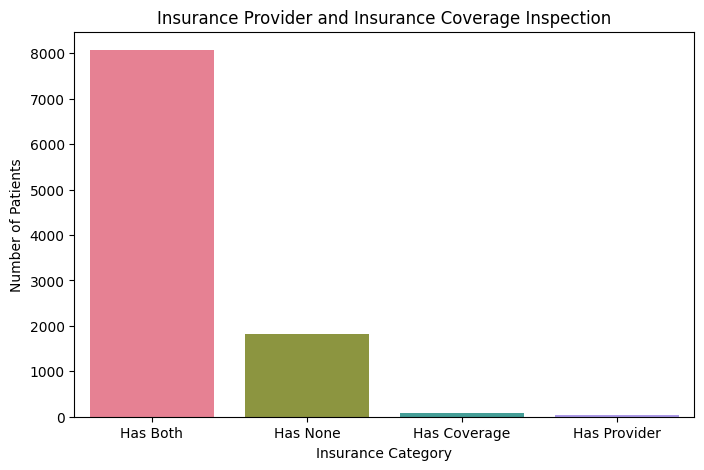

In [183]:
plt.figure(figsize=(8, 5))
sns.barplot(x=['Has Both', 'Has None', 'Has Coverage', 'Has Provider'], y=pd.Series(insurance.value_counts()), palette='husl')
plt.title("Insurance Provider and Insurance Coverage Inspection")
plt.xlabel('Insurance Category')
plt.ylabel("Number of Patients")
plt.show()

- Has Both: do nothing;
- Has None: fill `Insurance Provider` with None and `Insurance Coverage` with 0.0;
- Has Coverage: check if the `Insurance Provider` is stated in another cell beloging to that patient;
- Has Provider: fill in `Insurance Coverage` with 0.0.

**HAS NONE**

the ones that don't have insurance coverage either that is 0.0 or NaN

In [184]:
patients_with_nan_insurance_provider_nan_insurance_coverage = data.index[(data['Insurance Provider'].isna()) & ((data['Insurance Coverage'] == 0.0) | (data['Insurance Coverage'].isna()))].unique()

In [185]:
patients_rows_has_none = data.loc[data.index.isin(patients_with_nan_insurance_provider_nan_insurance_coverage)]
for patient_id in patients_rows_has_none.index:
    data.loc[patient_id, 'Insurance Provider'] = 'None'
    data.loc[patient_id, 'Insurance Coverage'] = 0.0

In [186]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         9916 non-null   object        
 5   Family History             8015 non-null   object        
 6   Education Level            9979 non-null   object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

In [187]:
patient

1012

**HAS COVERAGE**

In [188]:
patients_with_nan_insurance_provider = data.index[data['Insurance Provider'].isna()].unique()

In [189]:
patients_rows_has_coverage = data.loc[data.index.isin(patients_with_nan_insurance_provider)]
insurance_provider_of_patients = (patients_rows_has_coverage.groupby(level=0)['Insurance Provider']
                                  .apply(lambda x: x.dropna().iloc[0] if x.dropna().size > 0 else None)
)
insurance_provider_of_patients

Patient ID
1013          None
1014          None
1015    Provider B
1028    Provider D
1031    Provider C
1034    Provider C
1038    Provider B
1088    Provider B
1089    Provider C
1092    Provider C
1100    Provider C
1103    Provider B
1105    Provider D
1121    Provider B
1135    Provider D
1143    Provider A
1234    Provider A
1245    Provider A
1248    Provider A
1260    Provider D
1261    Provider C
1266    Provider C
1272    Provider B
1285    Provider A
1294    Provider D
1302    Provider A
1308    Provider A
1317    Provider C
1333    Provider B
1340    Provider A
1343    Provider A
1381    Provider D
1449    Provider D
1451    Provider B
1455    Provider A
1485    Provider D
1490    Provider D
1498    Provider D
Name: Insurance Provider, dtype: object

In [190]:
for patient_id in patients_with_nan_insurance_provider:
    provider = insurance_provider_of_patients.get(patient_id)
    if provider is not None:
        data.loc[patient_id, 'Insurance Provider'] = provider
    else:
        data.loc[patient_id, 'Insurance Provider'] = 'None'

In [191]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         10008 non-null  object        
 5   Family History             8015 non-null   object        
 6   Education Level            9979 non-null   object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

**HAS PROVIDER**

First, let's check if in our dataset exist case of patients that have insurance provider and the insurance coverage is 0.

In [192]:
patients_with_provider = data[data['Insurance Provider'] != 'None']

In [193]:
patients_with_provider[patients_with_provider['Insurance Coverage'] == 0.0]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
Patient ID,,,,,,,,,,,,,,,


In [194]:
#ver relação provider, departamento e insurance coverage
index_missing_coverage_with_provider = patients_with_provider.index[patients_with_provider['Insurance Coverage'].isna()].unique()
missing_coverage_with_provider = data.loc[data.index.isin(index_missing_coverage_with_provider)]
missing_coverage_with_provider.groupby(['Insurance Provider'])['Insurance Coverage'].count()

Insurance Provider
Provider B    226
Provider D    166
Name: Insurance Coverage, dtype: int64

In [195]:
patients_with_insurance_provider = data.index[data['Insurance Provider'] != 'None'].unique()
patients_rows_has_insurance_provider = data.loc[data.index.isin(patients_with_insurance_provider)]

In [196]:
# for patient_id in patients_rows_has_insurance_provider.index:
#     data.loc[patient_id, 'Insurance Coverage'] = 0.0


In [197]:
# rows in which the insurance coverage is bigger than the consultation price
data_provider_d = data[~(data['Insurance Coverage'].isna()) & (data['Insurance Provider'] != 'None')]
data_provider_d[(data_provider_d['Consultation Price'] < data_provider_d['Insurance Coverage']) & (data_provider_d['Insurance Provider'] == 'Provider D')]


,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
Patient ID,,,,,,,,,,,,,,,
1443,16.0,Male,Belfast,Student,Provider D,NaN,High school,Single,2024-01-22,General Practice,44,1,0.0,83.232090,93.232090
1230,40.0,Male,Edinburgh,Artist,Provider D,NaN,PhD,Divorced,2024-02-03,Emergency,105,4,83886.0,396.312644,400.312644
1028,41.0,Male,Birmingham,Engineer,Provider D,Diabetes,Undergraduate,Married,2024-04-12,Gastroenterology,118,5,48428.0,199.216286,299.216286


In [198]:
# changing all the values where the value of insurance coverage is bigger than the consultation price
provider_d = (
    ~(data['Insurance Coverage'].isna()) &
    (data['Insurance Provider'] != 'None') &
    (data['Consultation Price'] < data['Insurance Coverage']) &
    (data['Insurance Provider'] == 'Provider D')
)

data.loc[provider_d, 'Insurance Coverage'] = data.loc[provider_d, 'Consultation Price']

In [199]:
# through this we see that Provider D always covers all of the Consultation Price 
data_provider_d = data[~(data['Insurance Coverage'].isna()) & (data['Insurance Provider'] != 'None')]
data_provider_d2 = data_provider_d[(data_provider_d['Insurance Provider'] == 'Provider D') & 
                                   ~(data_provider_d['Consultation Price'] == data_provider_d['Insurance Coverage'])]
data_provider_d2

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
Patient ID,,,,,,,,,,,,,,,


In [200]:
# fill missing values in Insurance Coverage (for Insurance Provider D) with the Consultation Price

provider_d_missing = (data['Insurance Coverage'].isna()) & (data['Insurance Provider'] == 'Provider D')
data.loc[provider_d_missing, 'Insurance Coverage'] = data.loc[provider_d_missing, 'Consultation Price']

In [201]:
# every Insurance Coverage is 90% of the Consultation Price except when the Insurance Coverage is bigger than the Consultation Price
data_provider_b = data.loc[
    ~(data['Insurance Coverage'].isna()) & 
    (data['Insurance Provider'] == 'Provider B')
]
# we assume this is a mistake as the insurance coverage is bigger than consultation price
# assume what happened i all the other cases from this provider, the insurance covered 90% of consultation price
data_provider_b['Coverage Percentage'] = (data_provider_b['Insurance Coverage'] / data_provider_b['Consultation Price']).round(2)
data_provider_b[data_provider_b['Coverage Percentage']!=0.9]



,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage,Coverage Percentage
Patient ID,,,,,,,,,,,,,,,,
1344,18.0,Other,Birmingham,Student,Provider B,NaN,High school,Single,2024-03-20,Emergency,105,4,0.0,357.653151,421.887836,1.18
1021,14.0,Male,London,Student,Provider B,NaN,High school,Single,2024-03-13,General Practice,44,6,0.0,50.047001,55.042301,1.10


In [202]:
provider_b_mistakes = data_provider_b = data['Insurance Coverage'].notna() & (data['Insurance Provider'] == 'Provider B') & (data['Insurance Coverage'] > data['Consultation Price'])

data.loc[provider_b_mistakes, 'Insurance Coverage'] = data.loc[provider_b_mistakes, 'Consultation Price']*0.9

In [203]:
provider_b_missing = (data['Insurance Coverage'].isna()) & (data['Insurance Provider'] == 'Provider B')
data.loc[provider_b_missing, 'Insurance Coverage'] = data.loc[provider_b_missing, 'Consultation Price']*0.9

In [204]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         10008 non-null  object        
 5   Family History             8015 non-null   object        
 6   Education Level            9979 non-null   object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

**THE MISSING VALUES IN `Insurance Provider` and `Insurance Coverage` ARE NOW FILLED**

Fill in missing values in Family History.

In [205]:
patients_with_nan_family_history = data.index[data['Family History'].isna()].unique()

In [206]:
patients_rows = data.loc[data.index.isin(patients_with_nan_family_history)]
family_history_of_patients = patients_rows.groupby(patients_rows.index)['Family History'] \
                                      .apply(lambda x: x.iloc[0])
family_history_of_patients

Patient ID
1005   NaN
1009   NaN
1011   NaN
1021   NaN
1025   NaN
        ..
1454   NaN
1462   NaN
1480   NaN
1488   NaN
1490   NaN
Name: Family History, Length: 99, dtype: float64

All the patients with missing values in Family History have all the other rows with NaN's as well. 

In [207]:
data['Family History'] = data['Family History'].fillna('Unknown')

In [208]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         10008 non-null  object        
 5   Family History             10008 non-null  object        
 6   Education Level            9979 non-null   object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

Analyse what kind of missing values the ones in Education Level and Approximate Annual Income as they could be MAR

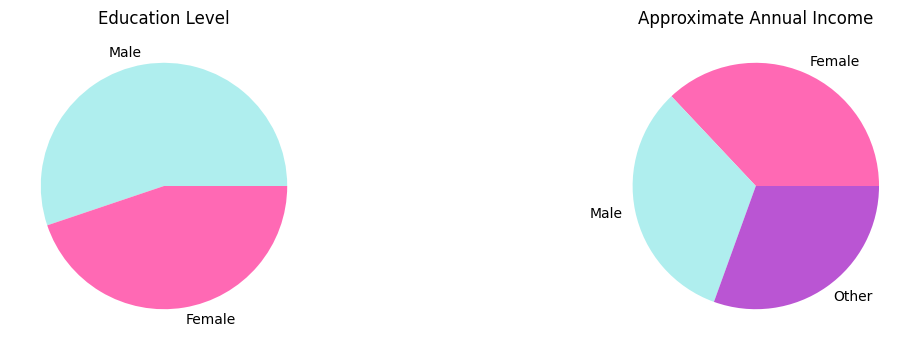

In [209]:
na_analysis = data[['Gender', 'Education Level', 'Approximate Annual Income']].fillna('Empty')
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14,4))
pie_colors = {'Male': 'paleturquoise', 'Female': 'hotpink', 'Other': 'mediumorchid'}

for i in range(2):
    ax = [ax1,ax2][i]
    col = ['Education Level', 'Approximate Annual Income'][i]
    pie_data = na_analysis[na_analysis[col]=='Empty']['Gender'].value_counts().reset_index()
    colors = [pie_colors[label] for label in pie_data['Gender']]
    ax.pie(pie_data.iloc[:,1], labels=pie_data.iloc[:,0], colors=colors)
    ax.set_title(col)
plt.show()

The missing values in these columns don't seem to be dependent on gender, so they could be MCAR

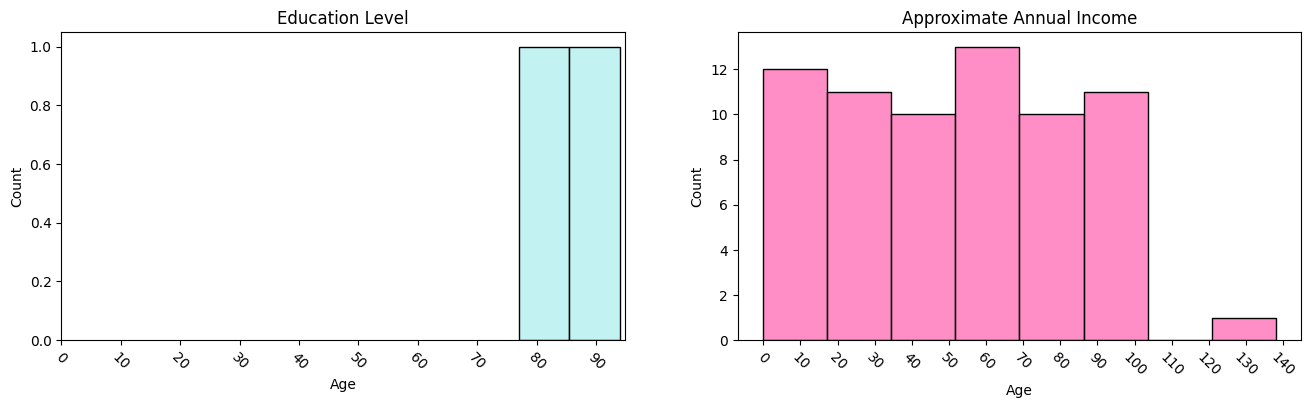

In [210]:
na_analysis = data[['Age', 'Education Level', 'Approximate Annual Income']].fillna('Empty')
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(16,4))
colors=['paleturquoise', 'hotpink', 'mediumorchid']

for i in range(2):
    ax = [ax1,ax2][i]
    col = ['Education Level', 'Approximate Annual Income'][i]
    hist_data = na_analysis[na_analysis[col]=='Empty']['Age'].value_counts().reset_index()
    sns.histplot(hist_data, ax=ax, x='Age', color=colors[i])
    ax.set_xticks(np.arange(0,hist_data.sort_values(by='Age').iloc[-1,0]+6,10))
    ax.tick_params(axis='x', labelrotation=-45)
    ax.set_title(col)
plt.show()

The missing values in Education Level seem to be dependent on Age, which makes them MAR, while the other column still seem to be MCAR

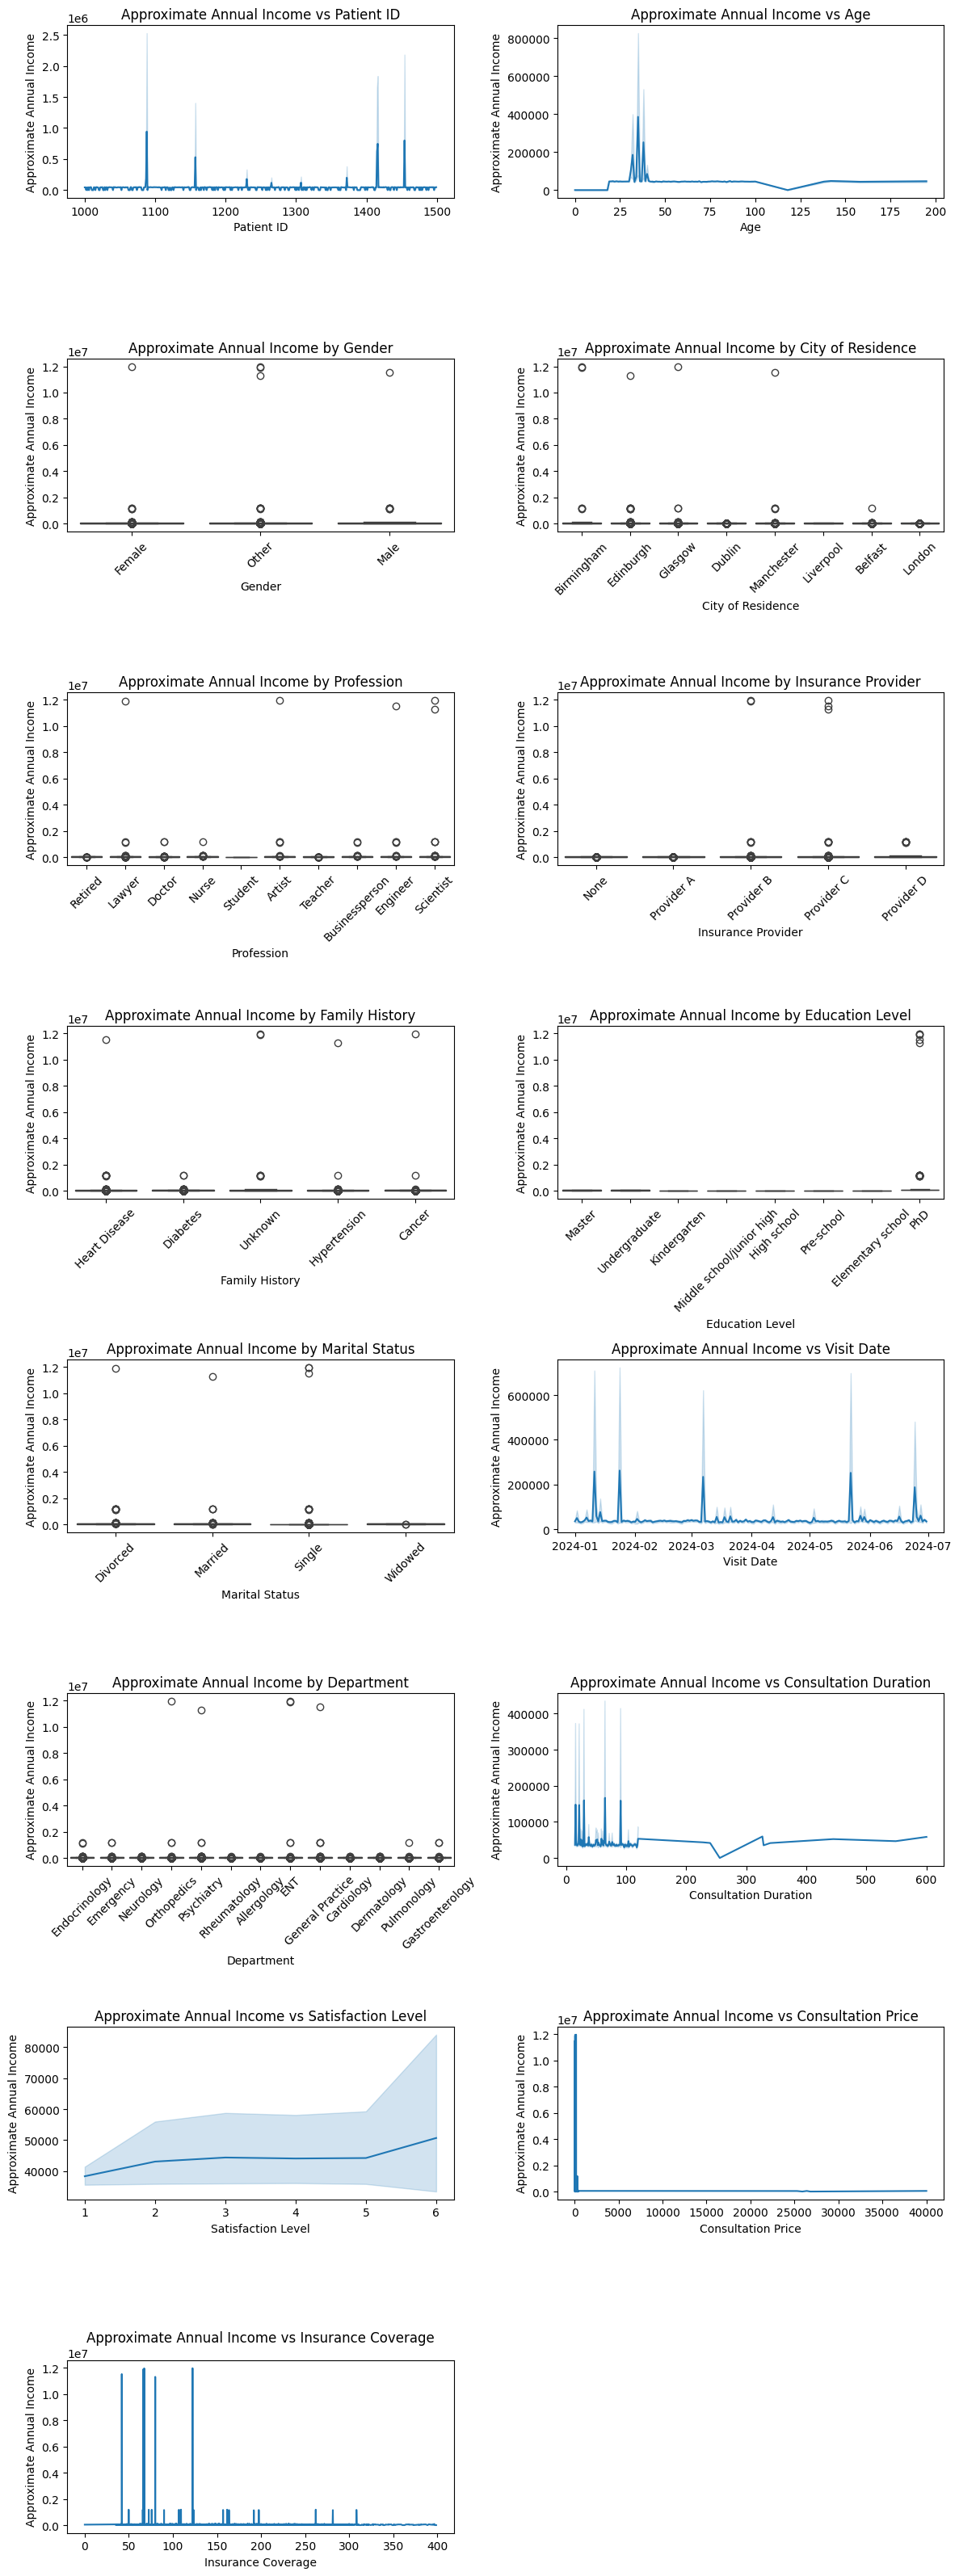

In [211]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

data_reset = data.reset_index(drop=False)
target_col = 'Approximate Annual Income'

# Columns to plot (exclude target)
cols_to_plot = [col for col in data_reset.columns if col != target_col]
n_cols = 2  # number of subplots per row
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    
    if data_reset[col].dtype == 'object':
        sns.boxplot(x=col, y=target_col, data=data_reset, ax=ax)
        ax.set_title(f'{target_col} by {col}')
        ax.tick_params(axis='x', rotation=45)
    else:
        sns.lineplot(x=col, y=target_col, data=data_reset, ax=ax)
        ax.set_title(f'{target_col} vs {col}')

# Remove any empty subplots if columns < n_rows*n_cols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
#fig.savefig('income_vs_features.png', dpi=300)  # save figure as PNG
plt.show()

**STUDENT AND RETIRED HAVE THE MOST MISSING VALUES ON INCOME** - all people with NaN on income have declared their income in another row

In [212]:
patients_with_nan_income = data.index[data['Approximate Annual Income'].isna()].unique()
patients_rows_income = data.loc[data.index.isin(patients_with_nan_income)]

In [213]:
# income_of_patients = patients_rows.groupby(patients_rows.index)['Approximate Annual Income'] \
#                                   .apply(lambda x: x.dropna().iloc[0] if not x.dropna().empty else None)

# for patient in patients_with_nan_income:
#     income_to_fill_in_with = income_of_patients.get(patient)
#     if income_to_fill_in_with is not None:
#         data.loc[patient, 'Approximate Annual Income'] = data.loc[patient, 'Approximate Annual Income'].fillna(income_to_fill_in_with)

In [214]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         10008 non-null  object        
 5   Family History             10008 non-null  object        
 6   Education Level            9979 non-null   object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

Fill Missing At Random Values

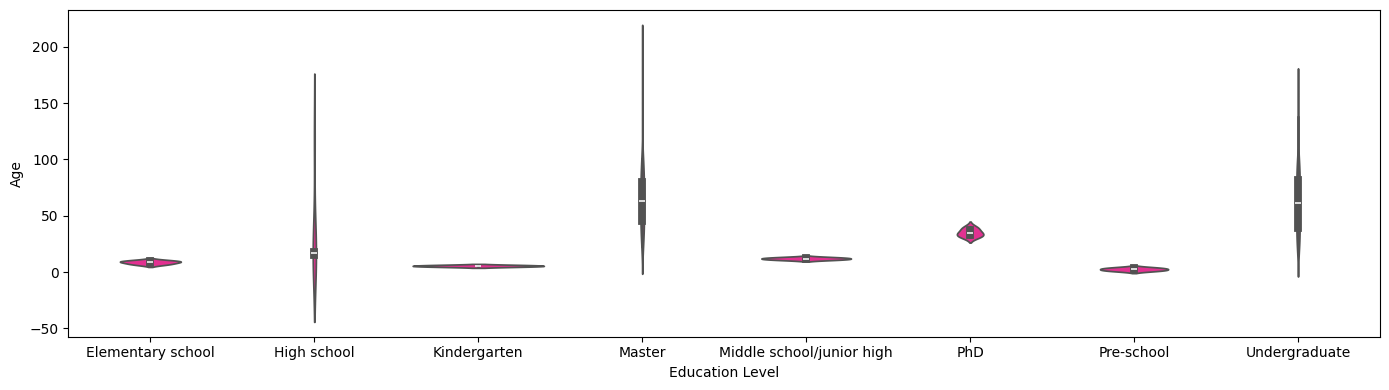

In [215]:
fig, ax = plt.subplots(figsize=(14,4))
education = data.reset_index()[['Education Level', 'Age', 'Patient ID']].drop_duplicates().groupby('Education Level')[['Education Level', 'Age']]
sns.violinplot(data=education.value_counts().reset_index().replace(0, np.nan).dropna(), x='Education Level', y='Age', color='deeppink')
plt.tight_layout()

Fill MAR Values

In [216]:
patients_with_nan_edu_level = data.index[data['Education Level'].isna()].unique()
patients_rows_edu_level = data.loc[data.index.isin(patients_with_nan_edu_level)]
edu_level_patients = patients_rows_edu_level.groupby(patients_rows_edu_level.index)['Education Level'] \
                                  .apply(lambda x: x.dropna().iloc[0] if not x.dropna().empty else None)

for patient in patients_with_nan_edu_level:
    level_to_fill_in_with = edu_level_patients.get(patient)
    if level_to_fill_in_with is not None:
        data.loc[patient, 'Education Level'] = data.loc[patient, 'Education Level'].fillna(level_to_fill_in_with)

In [217]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         10008 non-null  object        
 5   Family History             10008 non-null  object        
 6   Education Level            10008 non-null  object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

In [218]:
missing_income_by_profession = data.groupby('Profession')['Approximate Annual Income'].apply(lambda x: x.isna().sum())
print(missing_income_by_profession)

Profession
Artist             4
Businessperson    11
Doctor             6
Engineer          11
Lawyer            12
Nurse             10
Retired           51
Scientist          7
Student           35
Teacher            7
Name: Approximate Annual Income, dtype: int64


In [219]:
missing_income_by_education_level = data.groupby('Education Level')['Approximate Annual Income'].apply(lambda x: x.isna().sum())
print(missing_income_by_education_level)

Education Level
Elementary school             5
High school                  11
Kindergarten                  2
Master                       51
Middle school/junior high    10
PhD                           1
Pre-school                    7
Undergraduate                67
Name: Approximate Annual Income, dtype: int64


In [220]:
data.loc[data['Age'] == 0]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
Patient ID,,,,,,,,,,,,,,,
1301,0.0,Male,Dublin,Student,None,Unknown,Pre-school,Single,2024-06-17,Endocrinology,120,4,0.0,283.470109,0.000000
1301,0.0,Male,Dublin,Student,None,Unknown,Pre-school,Single,2024-02-10,Cardiology,83,2,0.0,270.378326,0.000000
1301,0.0,Male,Dublin,Student,None,Unknown,Pre-school,Single,2024-04-18,Cardiology,32,3,0.0,240.519387,0.000000
1301,0.0,Male,Dublin,Student,None,Unknown,Pre-school,Single,2024-01-25,Neurology,49,4,0.0,229.535112,0.000000
1301,0.0,Male,Dublin,Student,None,Unknown,Pre-school,Single,2024-02-10,Orthopedics,75,2,0.0,228.888516,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,0.0,Female,Glasgow,Student,Provider C,Unknown,Pre-school,Single,2024-01-07,ENT,82,2,0.0,77.618669,54.333068
1304,0.0,Female,Glasgow,Student,Provider C,Unknown,Pre-school,Single,2024-04-18,General Practice,24,1,0.0,73.179762,51.225834
1304,0.0,Female,Glasgow,Student,Provider C,Unknown,Pre-school,Single,2024-01-23,General Practice,39,6,0.0,52.804263,36.962984


In [221]:
# Filter rows for Students and Retired where income is not missing
subset = data[
    data['Profession'].isin(['Student', 'Retired']) &
    data['Approximate Annual Income'].notna()
]

# Check how many of these are 0.0
zero_income_counts = subset.groupby('Profession')['Approximate Annual Income'].apply(lambda x: (x == 0.0).sum())

# Optional: also see total non-missing counts for comparison
total_counts = subset.groupby('Profession')['Approximate Annual Income'].count()
print(pd.DataFrame({'non_missing': total_counts, 'zeros': zero_income_counts}))

            non_missing  zeros
Profession                    
Retired            3550     29
Student            2063   2063


In [222]:
data.loc[
    (data['Profession'] == 'Student') & (data['Approximate Annual Income'].isna()),
    'Approximate Annual Income'
] = 0.0

In [223]:
data.groupby(['Profession'])['Approximate Annual Income'].apply(lambda x: x.isna().sum())

Profession
Artist             4
Businessperson    11
Doctor             6
Engineer          11
Lawyer            12
Nurse             10
Retired           51
Scientist          7
Student            0
Teacher            7
Name: Approximate Annual Income, dtype: int64

In [224]:
data = data.reset_index()
data = data.sort_values(['Patient ID','Visit Date'])

income_missing = data[data['Approximate Annual Income'].isna()]
missing_index_list = income_missing.index.tolist()

for i in missing_index_list:

    if i==0:
        if data.loc[i, 'Patient ID'] == data.loc[i+1, 'Patient ID']:
            data.loc[i, 'Approximate Annual Income'] = data.loc[i+1, 'Approximate Annual Income']
    elif i == len(data)-1:
        if data.loc[i, 'Patient ID'] == data.loc[i-1, 'Patient ID']:
            data.loc[i, 'Approximate Annual Income'] = data.loc[i-1, 'Approximate Annual Income']
    
    else:
        same_before = data.loc[i, 'Patient ID'] == data.loc[i-1, 'Patient ID']
        same_after  = data.loc[i, 'Patient ID'] == data.loc[i+1, 'Patient ID']

        if same_before and same_after:

            before_date = abs((data.loc[i, 'Visit Date'] - data.loc[i-1, 'Visit Date']).days)
            after_date  = abs((data.loc[i+1, 'Visit Date'] - data.loc[i, 'Visit Date']).days)

            if before_date < after_date:
                data.loc[i, 'Approximate Annual Income'] = data.loc[i-1, 'Approximate Annual Income']
            else:
                data.loc[i, 'Approximate Annual Income'] = data.loc[i+1, 'Approximate Annual Income']

data = data.set_index("Patient ID", drop=True)

In [225]:
missing_values_income_profession = data.groupby(['Profession'])['Approximate Annual Income'].apply(lambda x: x.isna().sum())
missing_values_income_profession

Profession
Artist            2
Businessperson    4
Doctor            0
Engineer          1
Lawyer            0
Nurse             2
Retired           1
Scientist         0
Student           0
Teacher           0
Name: Approximate Annual Income, dtype: int64

In [226]:
income_median_profession = data.groupby('Profession')['Approximate Annual Income'].agg('median')
data.loc[data["Approximate Annual Income"].isna(), 'Approximate Annual Income'] = data.loc[data["Approximate Annual Income"].isna(), 'Profession'].map(income_median_profession)

In [227]:
d_map = {'Age': 'int16', 'Gender': 'category', 'City of Residence': 'category', 'Profession': 'category', 
        'Insurance Provider': 'category', 'Family History': 'category', 'Education Level': 'category', 
        'Marital Status': 'category', 'Department': 'category', 'Consultation Duration': 'int16',
        'Satisfaction Level': 'category', 'Satisfaction Level': 'int8', 'Approximate Annual Income': 'float32',
        'Consultation Price': 'float16', 'Insurance Coverage': 'float16'}
data = data.astype(d_map)

In [228]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1000 to 1499
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  int16         
 1   Gender                     10008 non-null  category      
 2   City of Residence          10008 non-null  category      
 3   Profession                 10008 non-null  category      
 4   Insurance Provider         10008 non-null  category      
 5   Family History             10008 non-null  category      
 6   Education Level            10008 non-null  category      
 7   Marital Status             10008 non-null  category      
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  category      
 10  Consultation Duration      10008 non-null  int16         
 11  Satisfaction Level         10008 non-null  int8          
 12  Approxi

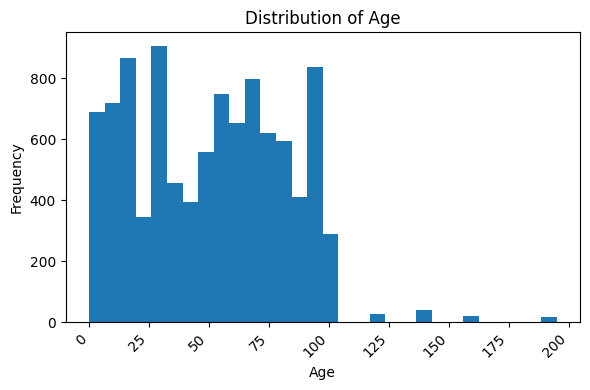

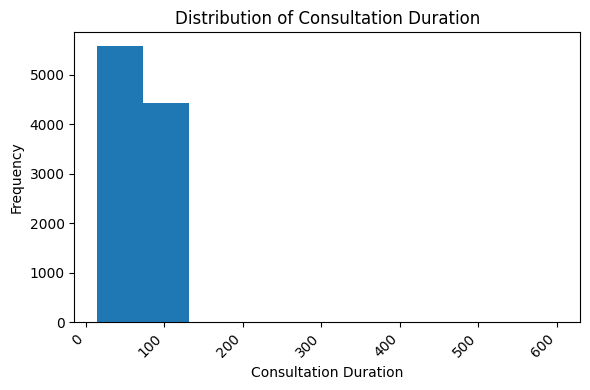

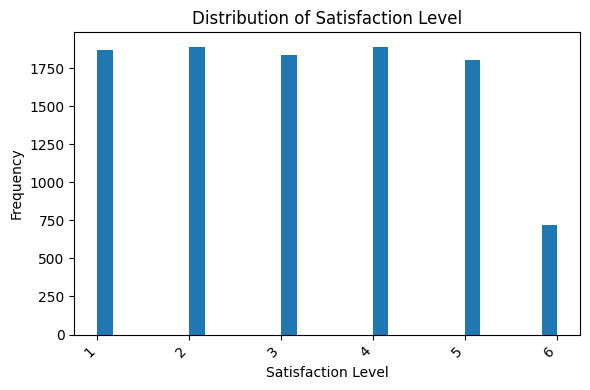

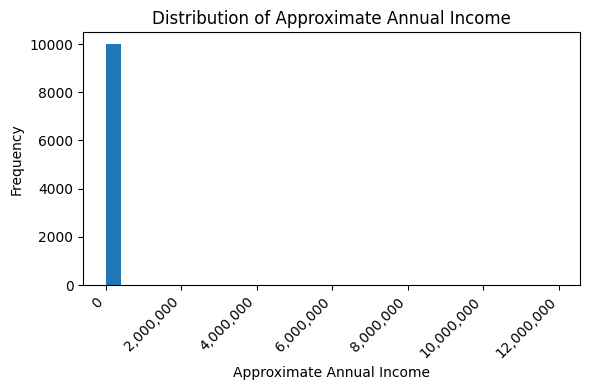

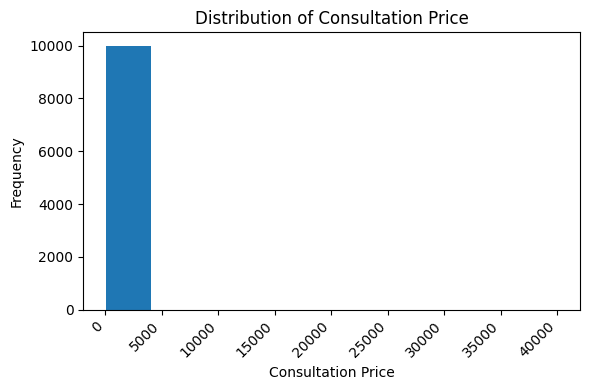

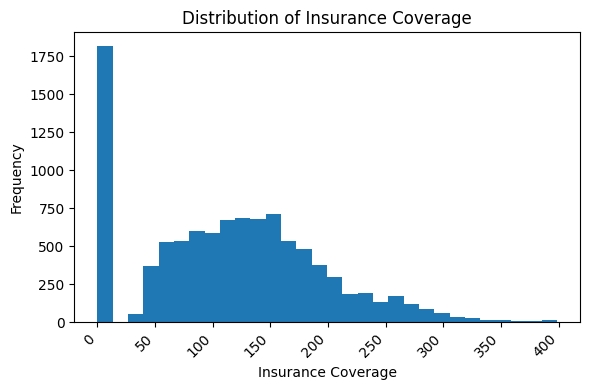

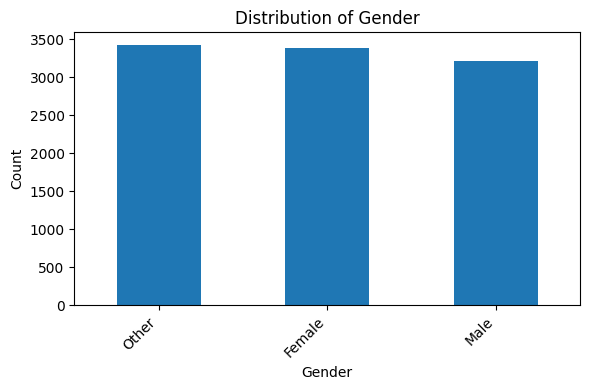

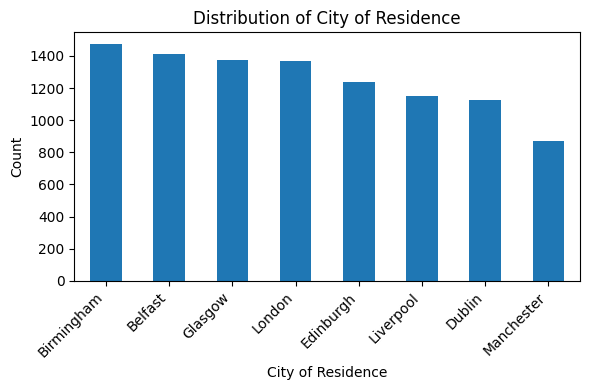

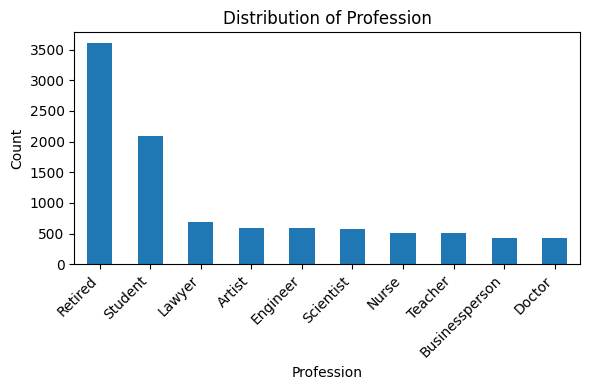

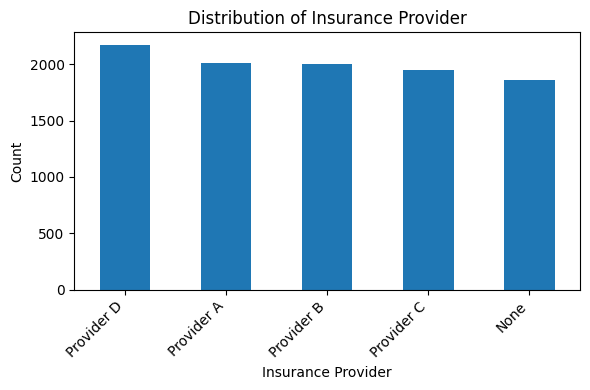

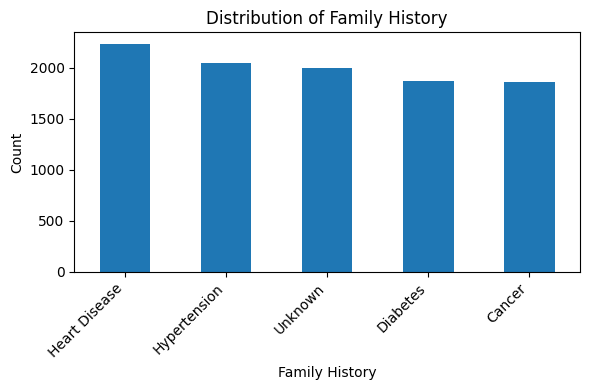

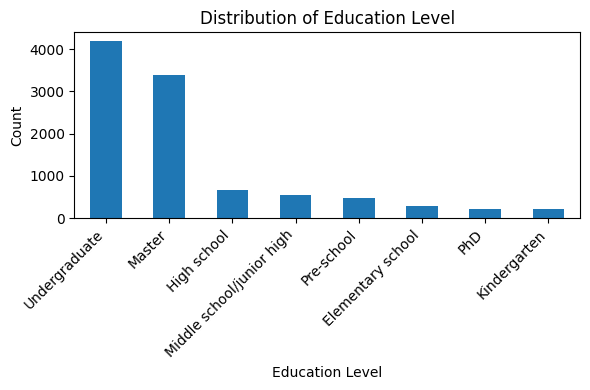

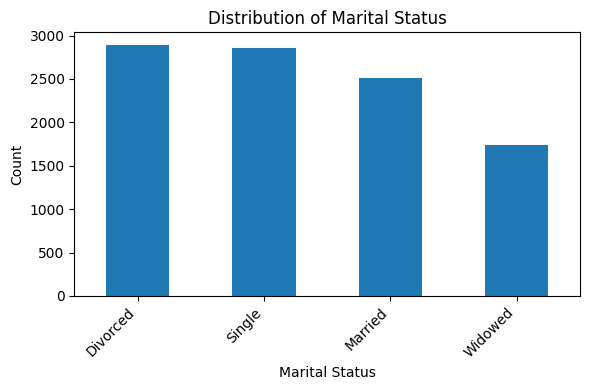

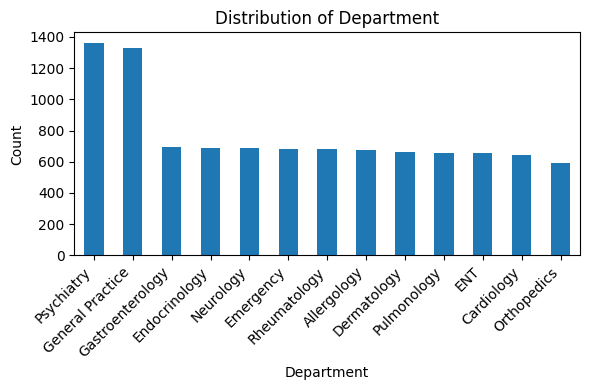

In [ ]:
numerical_features = data.select_dtypes(include=['number']).columns
categorical_features = data.select_dtypes(include=['category']).columns


for col in numerical_features:
    plt.figure(figsize=(6,4))
    plt.hist(data[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    if col == 'Approximate Annual Income':
        plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
    plt.xticks(rotation = 45, ha = 'right')
    plt.tight_layout()
    plt.show()

for col in categorical_features:
    plt.figure(figsize=(6,4))
    data[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation = 45, ha = 'right')
    plt.tight_layout()
    plt.show()


In [237]:
skewness = data[numerical_features].astype('float64').skew()
print(skewness)

Age                           0.285089
Consultation Duration         1.545225
Satisfaction Level            0.102142
Approximate Annual Income    42.533492
Consultation Price           39.858178
Insurance Coverage            0.322979
dtype: float64


Both Consultation Price and Income are very right-skewed --- DO LOGS

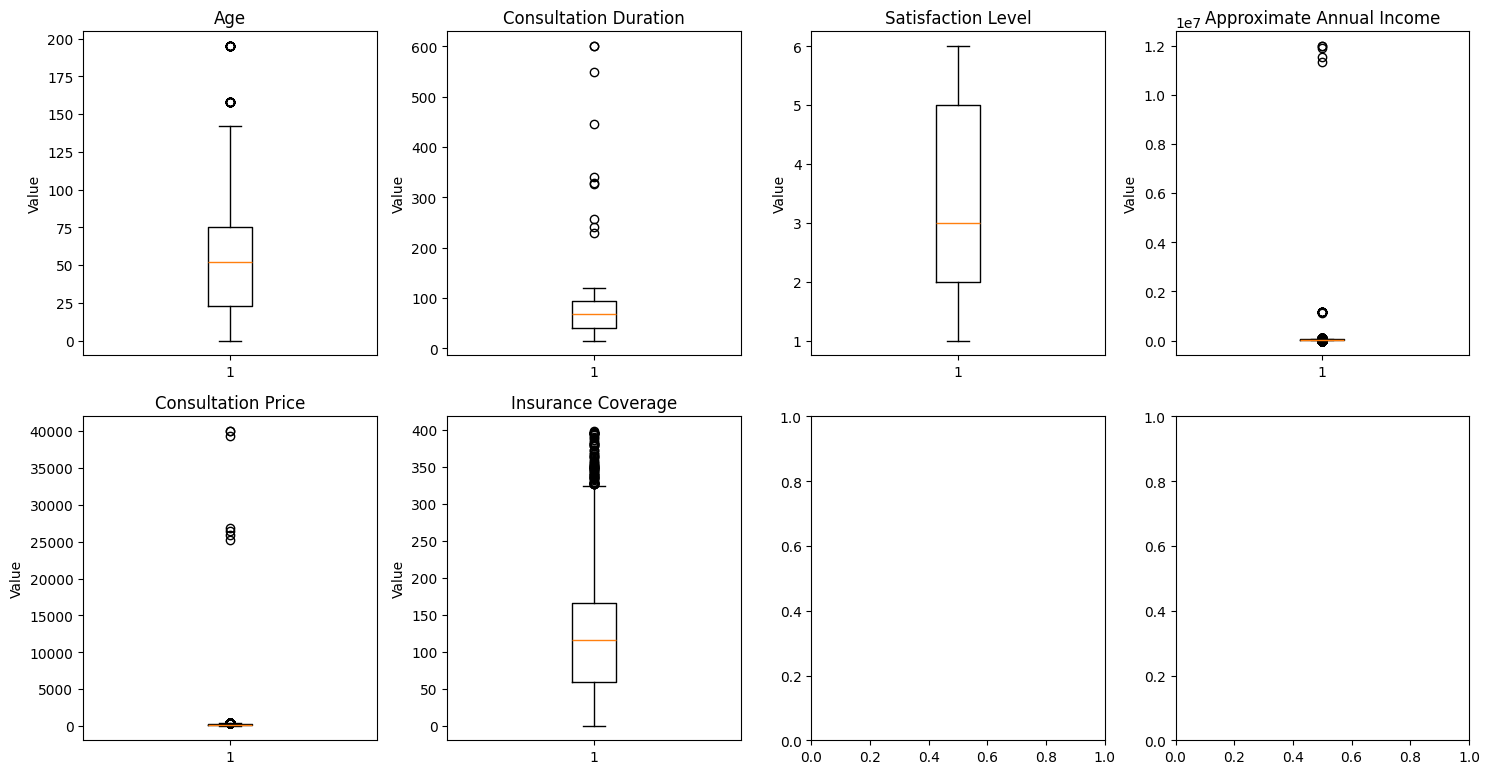

In [238]:
numeric_cols = data.select_dtypes(include=['number']).columns

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()  # turns axes into list

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(data[col].dropna())
    axes[i].set_title(f"{col}")
    axes[i].set_ylabel("Value")

plt.tight_layout()
plt.show()


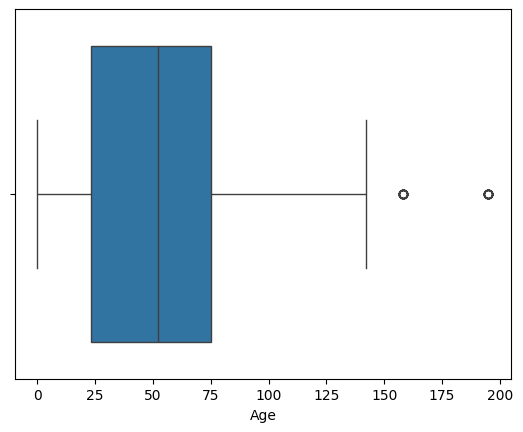

In [239]:
sns.boxplot(data=data, x='Age')
plt.show()

In [240]:
# consider that age above 125 was a mistake and replace by 125 biggest number we consider plausible  for Age
Q3 = data['Age'].quantile(0.75)
IQR = Q3 - data['Age'].quantile(0.25)
upper = Q3 + IQR # here we use k = 1 since the distribution is right-skewed and so the normal value for k (1.5) would lead to extreme values when clipping

data['Age'] = data['Age'].clip(upper=upper)

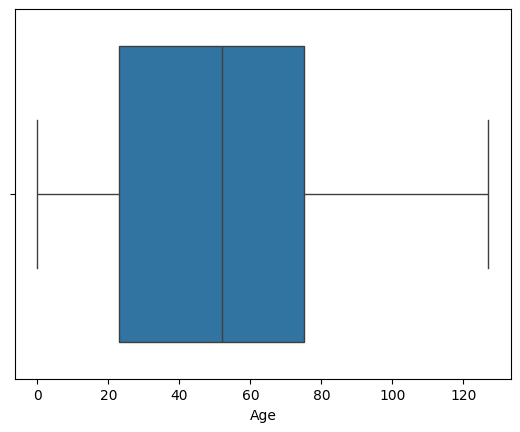

In [241]:
sns.boxplot(data=data, x='Age')
plt.show()

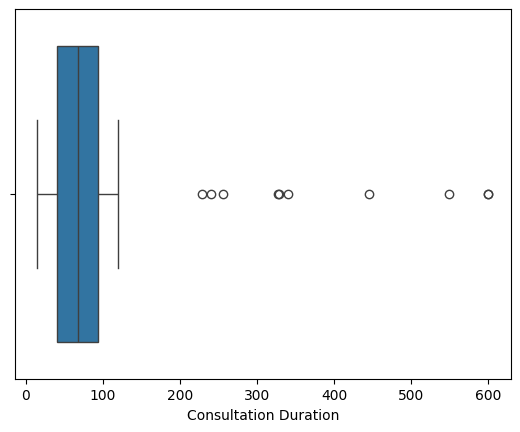

In [242]:
sns.boxplot(data=data, x='Consultation Duration')
plt.show()

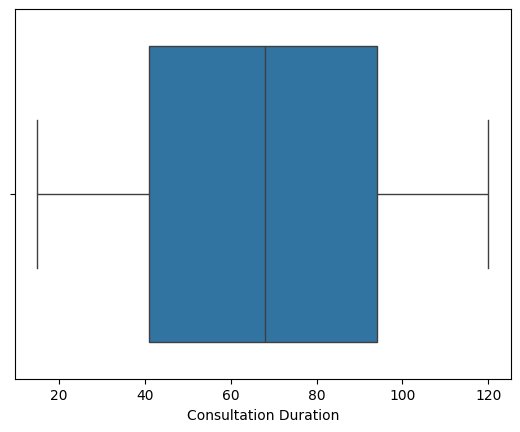

In [243]:
# detect outliers outside of bounds
Q1 = data['Consultation Duration'].quantile(0.25)
Q3 = data['Consultation Duration'].quantile(0.75)
IQR = Q3 -Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

# the outliers are when the value is bigger than upper
data_filtered = data[(data['Consultation Duration']<lower) | (data['Consultation Duration']>upper)]
data_filtered

# delete the values bigger than upper as they are impossible 
data = data[data['Consultation Duration']<= upper]

sns.boxplot(data=data, x='Consultation Duration')
plt.show()


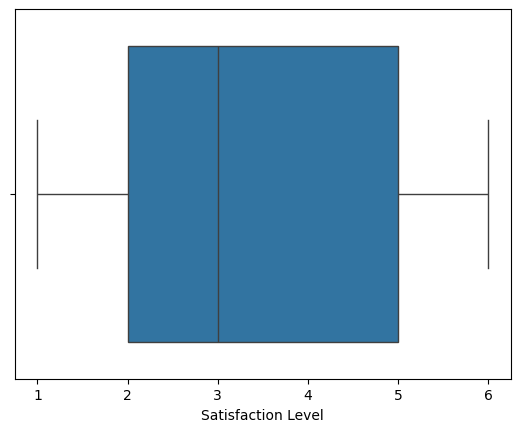

In [244]:
# as the satisfaction level can only be from 1-5 every value outside this bounds is an outlier
sns.boxplot(data=data, x='Satisfaction Level')
plt.show()

In [245]:
data['Satisfaction Level'] = data['Satisfaction Level'].clip(upper=5)

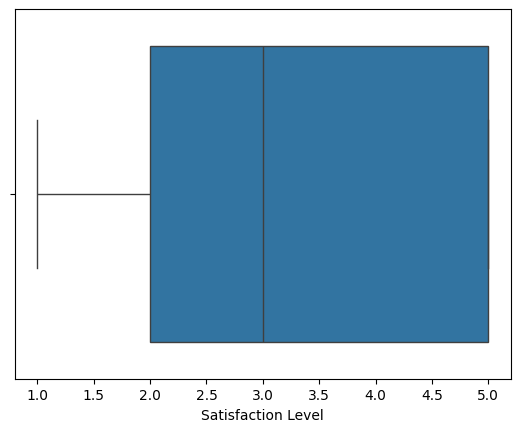

In [246]:
sns.boxplot(data=data, x='Satisfaction Level')
plt.show()

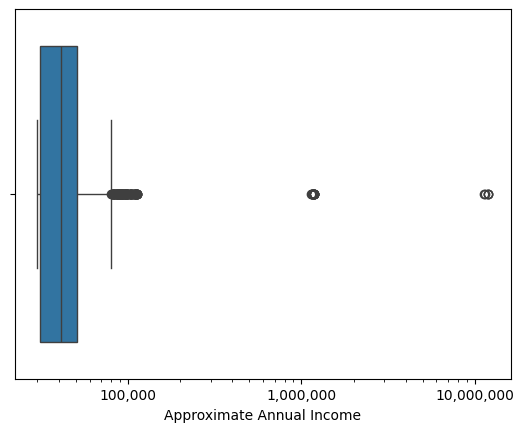

In [247]:
import matplotlib.ticker as mtick
sns.boxplot(data=data, x='Approximate Annual Income')
plt.xscale('log')
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

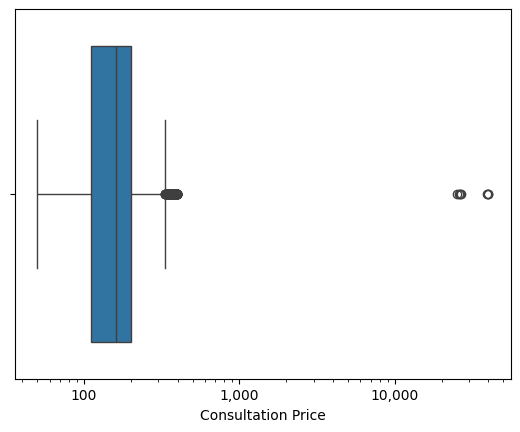

In [248]:
sns.boxplot(data=data, x='Consultation Price')
plt.xscale('log')
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

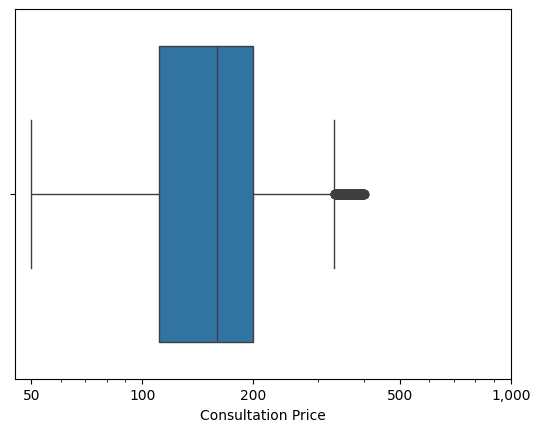

In [249]:
# we consider that values above 10 000 are mistakes so they will be removed
# high values before 1 000 although high are plausible
from matplotlib.ticker import LogFormatter
from matplotlib.ticker import LogLocator

data = data[data['Consultation Price']<10000]
sns.boxplot(data=data, x='Consultation Price')
plt.xscale('log')

ticks = [50, 100, 200, 500, 1000]
plt.xticks(ticks, [f"{t:,}" for t in ticks])
plt.show()

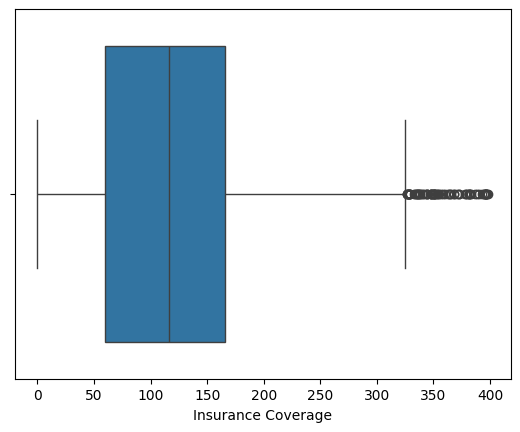

In [250]:
sns.boxplot(data=data, x='Insurance Coverage')
plt.show()

In [251]:
# the outliers that appear in the graph happen when consultation price is very high, so although the value for Insurance Coverage is high
# it's a plausible value and we do not consider it a mistake
data[data['Insurance Coverage']>300]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
Patient ID,,,,,,,,,,,,,,,
1000,127,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-01,Emergency,50,4,54388.0,381.25,381.25
1003,91,Male,Manchester,Retired,Provider A,Cancer,Master,Married,2024-04-01,Emergency,49,4,53760.0,376.75,301.50
1014,71,Male,Birmingham,Retired,None,Hypertension,Undergraduate,Divorced,2024-03-28,Emergency,112,2,34303.0,373.00,335.75
1015,1,Female,Manchester,Student,Provider B,Heart Disease,Pre-school,Single,2024-04-22,Emergency,111,3,0.0,360.50,324.50
1017,79,Female,Liverpool,Retired,Provider A,Diabetes,Undergraduate,Divorced,2024-03-23,Emergency,77,4,37431.0,397.00,317.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487,37,Female,Edinburgh,Businessperson,Provider D,Heart Disease,Undergraduate,Married,2024-03-20,Emergency,103,3,30103.0,394.50,394.50
1490,30,Female,Dublin,Scientist,Provider D,Unknown,Master,Single,2024-05-16,Emergency,88,5,53371.0,328.25,328.25
1492,43,Other,Liverpool,Teacher,Provider B,Cancer,Master,Widowed,2024-03-11,Emergency,38,5,40507.0,373.50,336.25


In [252]:
data[data.duplicated()]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
Patient ID,,,,,,,,,,,,,,,
1011,11,Female,London,Student,None,Unknown,Middle school/junior high,Single,2024-04-12,Psychiatry,101,1,0.0,133.3750,0.0000
1217,78,Other,London,Retired,None,Heart Disease,Undergraduate,Divorced,2024-05-03,Rheumatology,109,4,52131.0,164.3750,0.0000
1253,38,Other,Manchester,Engineer,Provider A,Hypertension,Master,Married,2024-03-25,Emergency,70,2,32726.0,355.5000,284.2500
1287,68,Male,Birmingham,Retired,Provider A,Cancer,Undergraduate,Widowed,2024-06-16,Rheumatology,99,4,37375.0,141.6250,113.3750
1306,91,Female,London,Retired,Provider D,Hypertension,Master,Widowed,2024-03-11,Orthopedics,32,1,33036.0,221.7500,221.7500
1330,60,Female,Manchester,Artist,None,Diabetes,Undergraduate,Married,2024-06-27,Orthopedics,118,1,48263.0,172.6250,0.0000
1363,18,Male,Glasgow,Student,Provider A,Unknown,High school,Single,2024-04-01,Allergology,61,4,0.0,126.7500,101.4375
1443,16,Male,Belfast,Student,Provider D,Unknown,High school,Single,2024-05-31,Psychiatry,45,5,0.0,113.0625,113.0625


In [253]:
data['Income_log'] = np.log(data['Approximate Annual Income'])
data['Consultation_price_log'] = np.log(data['Consultation Price'])
data['Insurance Coverage Percentage'] = (data['Insurance Coverage'].div(data['Consultation Price'])).round(2)

max_age = data['Age'].max()
age_bins = list(range(0, max_age + 5, 5))
age_labels = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins)-1)]
data['Age Range'] = pd.cut(data['Age'], bins=age_bins, labels=age_labels, include_lowest=True, right=True)

from datetime import datetime

import datetime

today = datetime.datetime.now()
diff = today - data['Visit Date']
data['Days since last visit'] = diff.dt.days

In [254]:
data

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage,Income_log,Consultation_price_log,Insurance Coverage Percentage,Age Range,Days since last visit
Patient ID,,,,,,,,,,,,,,,,,,,,
1000,127,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-01,Emergency,50,4,54388.0,381.2500,381.25000,10.903899,5.945312,1.000000,125-130,707
1000,127,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-05,Cardiology,88,1,35475.0,278.2500,278.25000,10.476583,5.628906,1.000000,125-130,703
1000,127,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-11,Rheumatology,56,2,31503.0,157.3750,157.37500,10.357838,5.058594,1.000000,125-130,697
1000,127,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-02-02,Allergology,98,1,53857.0,126.5000,126.50000,10.894088,4.839844,1.000000,125-130,675
1000,127,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-02-21,Psychiatry,69,1,45824.0,191.6250,191.62500,10.732563,5.253906,1.000000,125-130,656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499,74,Other,Liverpool,Retired,Provider C,Cancer,Undergraduate,Married,2024-04-13,General Practice,63,3,53392.0,85.4375,59.78125,10.885416,4.449219,0.700195,70-75,604
1499,74,Other,Liverpool,Retired,Provider C,Cancer,Undergraduate,Married,2024-04-27,Pulmonology,59,3,49238.0,133.2500,93.31250,10.804421,4.890625,0.700195,70-75,590
1499,74,Other,Liverpool,Retired,Provider C,Cancer,Undergraduate,Married,2024-05-05,Orthopedics,23,4,58955.0,209.2500,146.50000,10.984529,5.343750,0.700195,70-75,582


In [255]:
data = data.drop_duplicates()

In [256]:
data[data.duplicated()]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage,Income_log,Consultation_price_log,Insurance Coverage Percentage,Age Range,Days since last visit
Patient ID,,,,,,,,,,,,,,,,,,,,


# <span style="color:#2a9d8fff"> **Part B**: Feature Engineering and ABT construction</span> #

**Static attributes (demographics)**

In [257]:
aggregation = {'Age': 'max', 'Gender': 'first', 'City of Residence': 'last', 'Profession': 'last', 'Insurance Provider': 'last', 
               'Family History': 'last', 'Education Level': 'last', 'Marital Status': 'last','Visit Date': 'max', 'Approximate Annual Income': 'last', 
               'Department': list, 'Consultation Duration': 'mean', 'Satisfaction Level': 'mean', 'Consultation Price': 'mean', 'Insurance Coverage': 'mean', 'Income_log': 'last',
                 'Consultation_price_log': 'mean', 'Insurance Coverage Percentage': 'mean', 'Days since last visit': 'last','Age Range': 'last'}
abt = data.groupby(data.index)[data.columns].agg(aggregation)

columns_names= {'Visit Date': 'Last Visit Date', 'Department': 'All Departments Visited', 'Consultation Duration': 'Average Consultation Duration',
                'Satisfaction Level': 'Average Satisfaction Level', 'Consultation Price': 'Average Consultation Price', 
                'Insurance Coverage': 'Average Insurance Coverage', 'Insurance Coverage Percentage':'Average Insurance Coverage Percentage'}
abt = abt.rename(columns=columns_names)
abt.head()
abt['Last Visit Date'] = abt['Last Visit Date'].dt.strftime('%Y-%m-%d')
abt.to_csv('ABT_city_hospital.csv')
abt.head()

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Last Visit Date,Approximate Annual Income,All Departments Visited,Average Consultation Duration,Average Satisfaction Level,Average Consultation Price,Average Insurance Coverage,Income_log,Consultation_price_log,Average Insurance Coverage Percentage,Days since last visit,Age Range
Patient ID,,,,,,,,,,,,,,,,,,,,
1000,127,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-06-27,38259.0,"[Emergency, Cardiology, Rheumatology, Allergol...",65.700000,2.600000,175.203125,175.203125,10.552135,5.087110,1.000000,529,125-130
1001,55,Male,Liverpool,Lawyer,Provider C,Heart Disease,Undergraduate,Married,2024-06-27,57443.0,"[Rheumatology, Psychiatry, Emergency, General ...",60.500000,3.187500,149.804688,104.867188,10.958549,4.883545,0.700195,529,50-55
1002,10,Female,Liverpool,Student,Provider C,Cancer,Elementary school,Single,2024-06-23,0.0,"[Neurology, Psychiatry, General Practice, Orth...",71.055556,3.444444,162.166672,113.532990,-inf,5.020399,0.700195,533,5-10
1003,91,Male,Manchester,Retired,Provider A,Cancer,Master,Married,2024-06-29,44496.0,"[General Practice, Orthopedics, Endocrinology,...",61.400000,3.240000,179.440002,143.550003,10.703155,5.101328,0.799805,527,90-95
1004,11,Male,Glasgow,Student,Provider B,Cancer,Middle school/junior high,Single,2024-06-28,0.0,"[General Practice, Emergency, Emergency, Gastr...",62.653846,3.269231,172.528839,155.292068,-inf,5.034630,0.899902,528,10-15


how many days since last visit?, n_visits, coverage %

# <span style="color:#2a9d8fff"> **Part C**: Exploratory Visualization & Insights</span> #

**Distribution by Age**

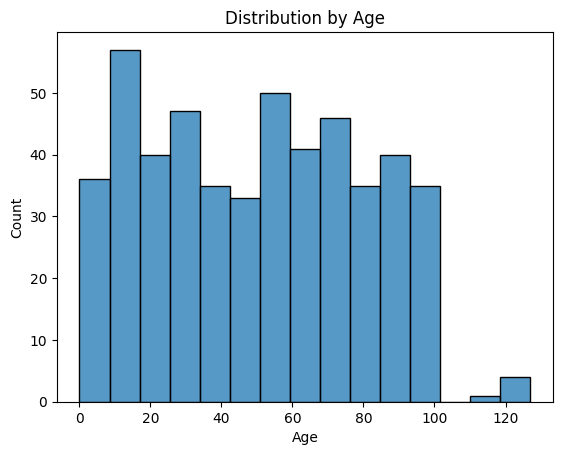

In [258]:
sns.histplot(data = abt, x = 'Age', bins = 15)
plt.title('Distribution by Age')
plt.show()

**Distribution by Gender**

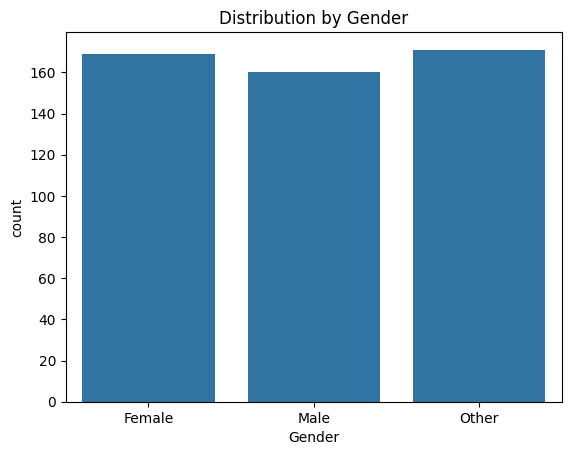

In [259]:
sns.countplot(data = abt, x='Gender')
plt.title('Distribution by Gender')
plt.show()

**Distribution by Annual Income**

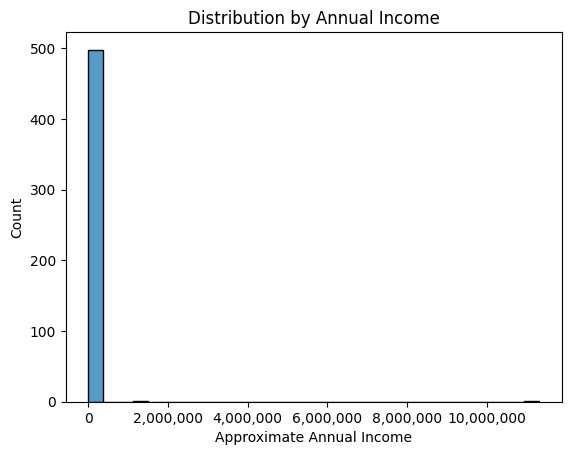

In [260]:
fig, ax = plt.subplots()
sns.histplot(data = abt, x = 'Approximate Annual Income', bins = 30)
plt.title('Distribution by Annual Income')
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

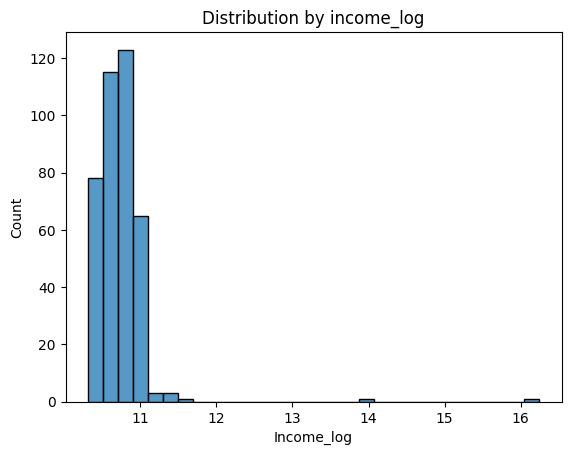

In [261]:
fig, ax = plt.subplots()
sns.histplot(data = abt, x = 'Income_log', bins = 30)
plt.title('Distribution by income_log')
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

**Number of visits per department and over time**

First, create a column of with the month of the visit.

In [262]:
data['Visit Month'] = data['Visit Date'].dt.to_period('M')
data.head()

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,...,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage,Income_log,Consultation_price_log,Insurance Coverage Percentage,Age Range,Days since last visit,Visit Month
Patient ID,,,,,,,,,,,,,,,,,,,,,
1000,127,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-01,Emergency,...,4,54388.0,381.250,381.250,10.903899,5.945312,1.0,125-130,707,2024-01
1000,127,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-05,Cardiology,...,1,35475.0,278.250,278.250,10.476583,5.628906,1.0,125-130,703,2024-01
1000,127,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-11,Rheumatology,...,2,31503.0,157.375,157.375,10.357838,5.058594,1.0,125-130,697,2024-01
1000,127,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-02-02,Allergology,...,1,53857.0,126.500,126.500,10.894088,4.839844,1.0,125-130,675,2024-02
1000,127,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-02-21,Psychiatry,...,1,45824.0,191.625,191.625,10.732563,5.253906,1.0,125-130,656,2024-02


Now, we can plot the graph.

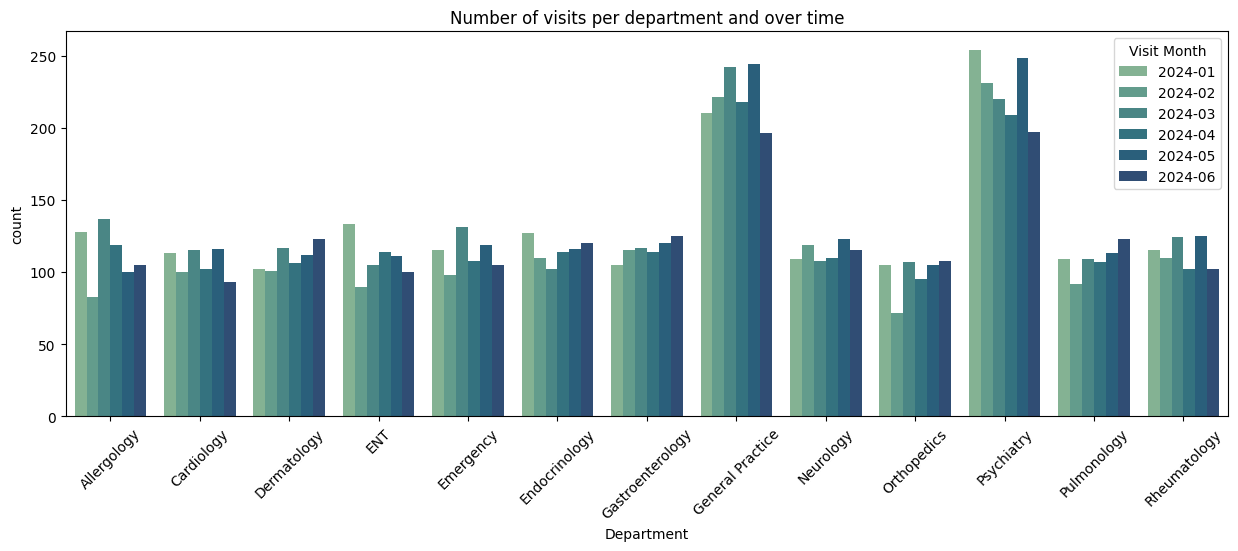

In [263]:
fig= plt.subplots(figsize = (15,5))
sns.countplot(data = data, x = 'Department', hue = 'Visit Month', palette = 'crest')
plt.xticks(rotation = 45)
plt.title('Number of visits per department and over time')
plt.show()

**Department by Gender**

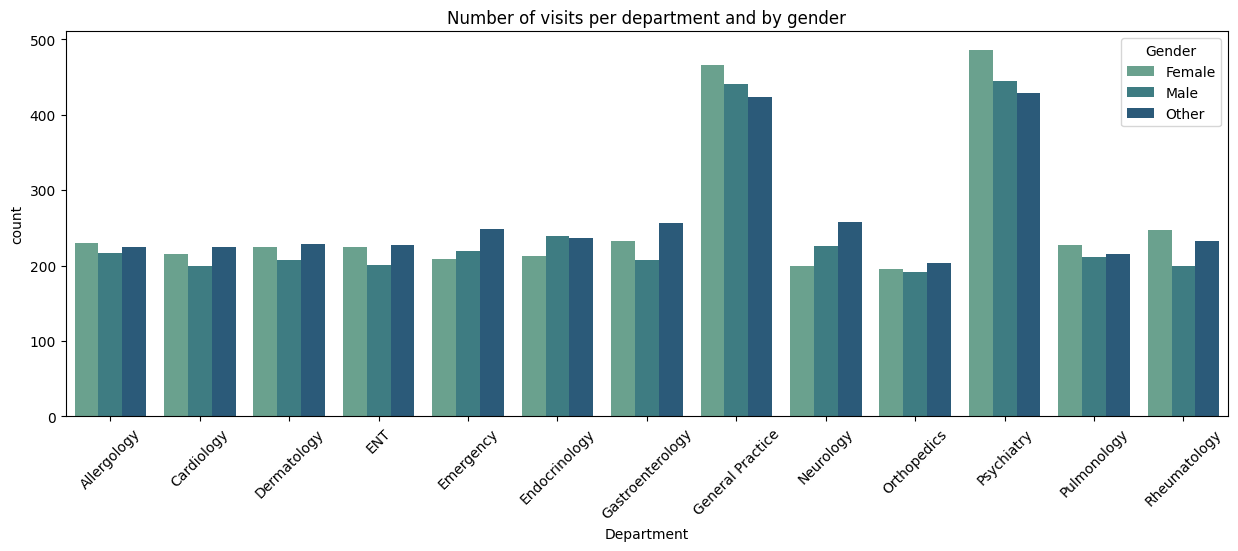

In [264]:
fig= plt.subplots(figsize = (15,5))
sns.countplot(data = data, x = 'Department', hue = 'Gender', palette = 'crest')
plt.xticks(rotation = 45)
plt.title('Number of visits per department and by gender')
plt.show()

**Department by Age**

In [276]:
data['Age Range']

Patient ID
1000    125-130
1000    125-130
1000    125-130
1000    125-130
1000    125-130
         ...   
1499      70-75
1499      70-75
1499      70-75
1499      70-75
1499      70-75
Name: Age Range, Length: 9983, dtype: category
Categories (26, object): ['0-5' < '5-10' < '10-15' < '15-20' ... '110-115' < '115-120' < '120-125' < '125-130']

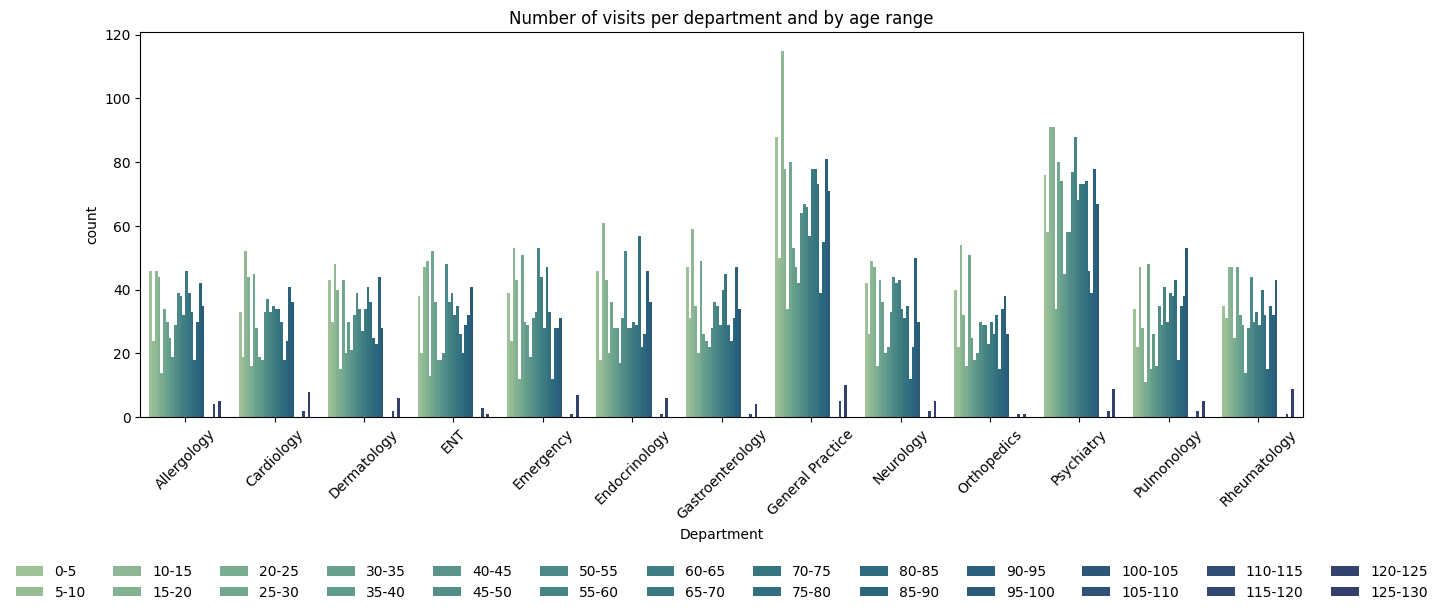

In [308]:
fig= plt.subplots(figsize = (15,5))
sns.countplot(data = data, x = 'Department', hue = 'Age Range', palette = 'crest')
plt.xticks(rotation = 45)
plt.title('Number of visits per department and by age range')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35),
           ncol=13, frameon=False)
plt.show()

**Distributions by Satisfaction Level**

In [341]:
data_to_plot.groupby('Age Range').describe()

Satisfaction Level                                          \
                       count      mean       std       min       25%   
Age Range                                                              
0-5                     13.0  2.987677  0.279671  2.659574  2.776316   
5-10                    13.0  3.325984  0.421920  2.708333  3.051724   
10-15                   13.0  3.033296  0.308919  2.632653  2.803279   
15-20                   13.0  3.185036  0.362836  2.785714  2.953488   
20-25                   13.0  3.185039  0.483974  2.500000  2.900000   
25-30                   13.0  3.141727  0.276720  2.770833  2.975000   
30-35                   13.0  3.200248  0.294383  2.733333  2.968750   
35-40                   13.0  3.062699  0.490766  2.500000  2.692308   
40-45                   13.0  3.263409  0.400164  2.555556  3.125000   
45-50                   13.0  3.067576  0.336487  2.727273  2.848485   
50-55                   13.0  3.089196  0.369200  2.482759  2.972222   
55-60                   13.0  3.145810  0.431843  2.482759  2.818182   
60-65                   13.0  2.936419  0.390098  2.259259  2.720930   
65-70                   13.0  3.137490  0.387044  2.676471  2.826087   
70-75                   13.0  3.135869  0.323009  2.578947  3.000000   
75-80                   13.0  3.103670  0.352527  2.606061  2.837838   
80-85                   13.0  3.034345  0.447031  2.000000  2.826087   
85-90                   13.0  3.106143  0.442297  2.318182  2.961538   
90-95                   13.0  3.029537  0.262153  2.552632  2.863636   
95-100                  13.0  3.183553  0.345993  2.766667  3.000000   
100-105                  0.0       NaN       NaN       NaN       NaN   
105-110                  0.0       NaN       NaN       NaN       NaN   
110-115                  0.0       NaN       NaN       NaN       NaN   
115-120                 13.0  3.014103  1.087723  1.000000  2.500000   
120-125                  0.0       NaN       NaN       NaN       NaN   
125-130                 13.0  2.635867  0.815521  1.000000  2.333333   

                                         
                50%       75%       max  
Age Range                                
0-5        2.860465  3.260870  3.556818  
5-10       3.272727  3.555556  4.040000  
10-15      3.018519  3.104167  3.744681  
15-20      3.065934  3.302326  3.897959  
20-25      3.187500  3.411765  4.076923  
25-30      3.069767  3.319149  3.634615  
30-35      3.200000  3.428571  3.722222  
35-40      3.066667  3.291667  4.222222  
40-45      3.404762  3.550000  3.722222  
45-50      3.000000  3.086207  3.843750  
50-55      3.135135  3.207792  3.750000  
55-60      3.095238  3.421053  3.861111  
60-65      2.886364  3.031250  3.719298  
65-70      3.100000  3.400000  3.937500  
70-75      3.068493  3.172414  3.800000  
75-80      3.093750  3.279070  3.692308  
80-85      3.080000  3.166667  3.800000  
85-90      3.129032  3.208333  4.137931  
90-95      3.031250  3.173913  3.468750  
95-100     3.056604  3.465116  3.829268  
100-105         NaN       NaN       NaN  
105-110         NaN       NaN       NaN  
110-115         NaN       NaN       NaN  
115-120    3.000000  4.000000  4.333333  
120-125         NaN       NaN       NaN  
125-130    2.600000  3.200000  4.000000

In [ ]:
data_to_plot = data.groupby(['Age Range', 'Department'])['Satisfaction Level'].mean().reset_index()

<Axes: xlabel='Age Range', ylabel='Department'>

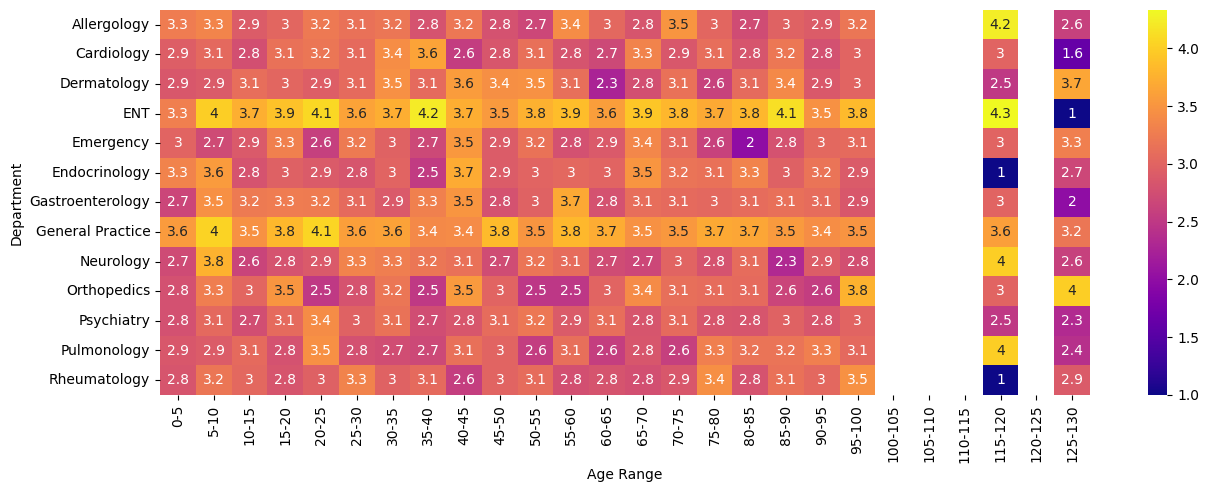

In [267]:
heatmap_data = data_to_plot.pivot(index='Department', 
                               columns='Age Range', 
                               values='Satisfaction Level'
                             )
fig= plt.subplots(figsize = (15,5))
sns.heatmap(heatmap_data, annot=True, cmap= 'plasma')

In [268]:
import plotly.express as px
fig = px.line(
    data_to_plot, 
    x='Age Range', 
    y='Satisfaction Level',  # Use the renamed column
    color='Department',        # Plotly's equivalent of 'hue'
    title='Average Satisfaction Level by Department and by Age Range',
    markers=True,              # Add markers to clearly show data points
    labels={'Satisfaction Level': 'Average Satisfaction Level'} # Customize axis label
)

# Customize the layout for better viewing
fig.update_layout(xaxis_tickangle=-45)
fig.show()

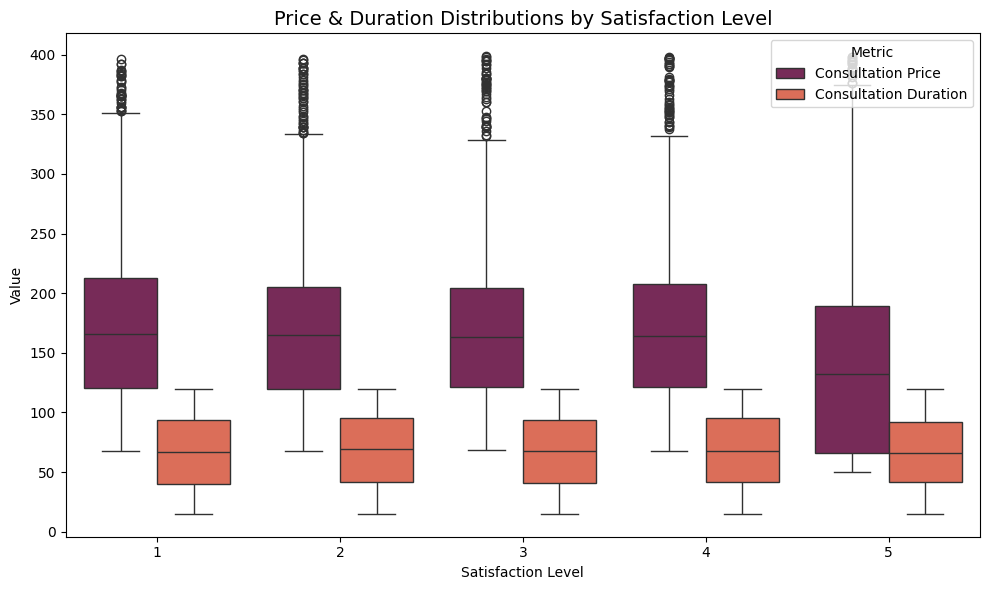

In [269]:
long_data = pd.melt(data, id_vars=['Satisfaction Level'], value_vars=['Consultation Price', 'Consultation Duration'],
                    var_name='Metric', value_name='Value')

fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=long_data, x='Satisfaction Level', y='Value', hue='Metric', palette='rocket', ax=ax)

ax.set_title("Price & Duration Distributions by Satisfaction Level", fontsize=14)
ax.set_xlabel("Satisfaction Level")
ax.set_ylabel("Value")
plt.legend(title="Metric", loc='upper right')
plt.tight_layout()
plt.show()

**Relationship between Consultation Price and Insurance Coverage by Insurance Provider**

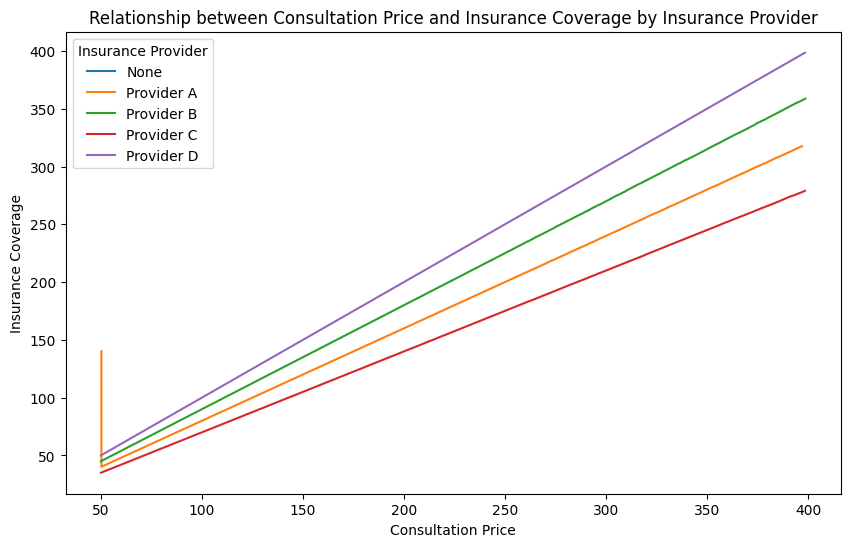

In [270]:
to_plot =data[data['Insurance Provider']!= 'None']
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(data=to_plot, x= 'Consultation Price', y='Insurance Coverage', hue='Insurance Provider', ax=ax)
ax.set_title("Relationship between Consultation Price and Insurance Coverage by Insurance Provider", fontsize=12)
plt.show()

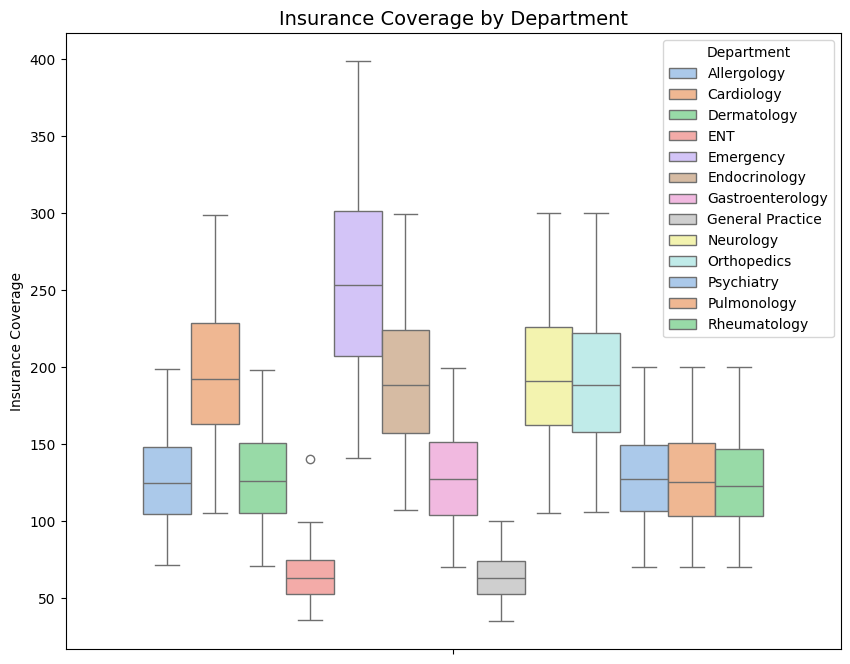

In [271]:
fig, ax = plt.subplots(figsize=(10,8))
sns.boxplot(data=to_plot, y='Insurance Coverage', hue='Department',ax=ax, palette='pastel' )
ax.set_title("Insurance Coverage by Department", fontsize=14)
plt.show()

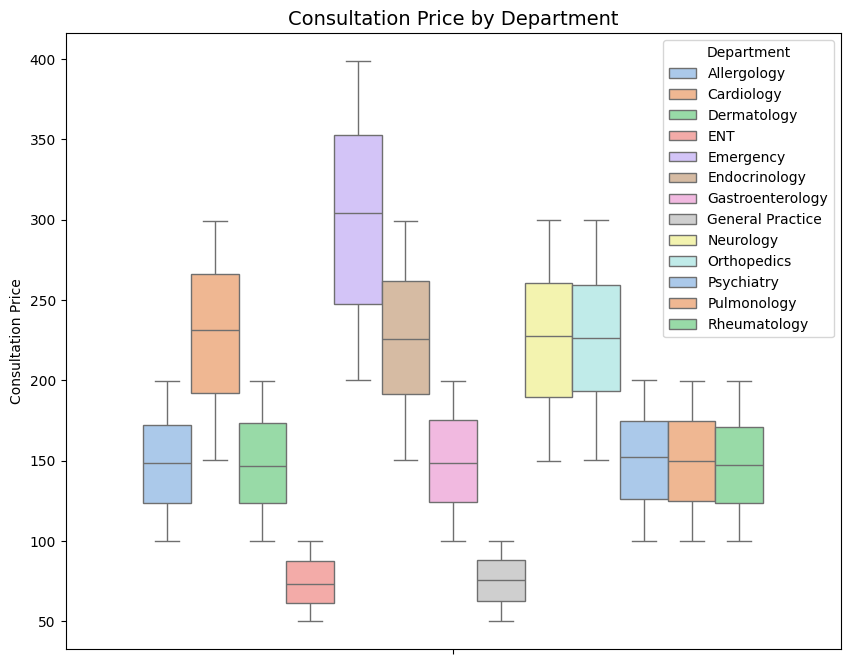

In [272]:
fig, ax = plt.subplots(figsize=(10,8))
sns.boxplot(data=to_plot, y='Consultation Price', hue='Department',ax=ax, palette='pastel')
ax.set_title("Consultation Price by Department", fontsize=14)
plt.show()

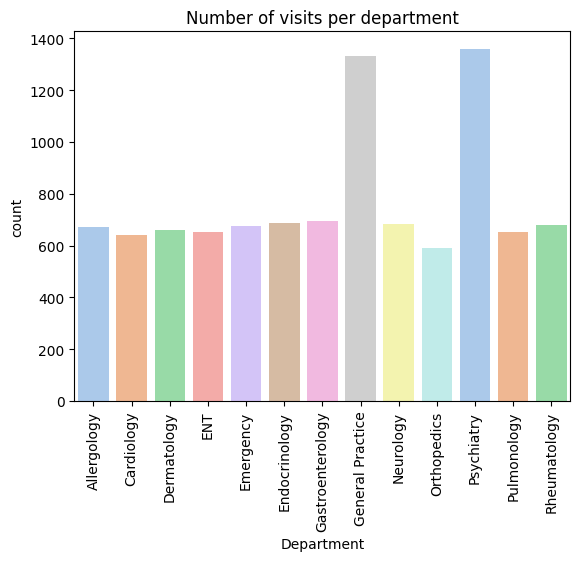

In [273]:
sns.countplot(data=data, x='Department', palette='pastel')
plt.xticks(rotation = 90)
plt.title('Number of visits per department')
plt.show()